# 🔁 Notebook 1: Retry with Exponential Backoff & Jitter

**The setup:** A flaky downstream service fails ~70% of the time. Naive code retries *instantly* — making the outage worse (a 'thundering herd' of clients all hammering the dying service at the same moment).

We'll evolve through three strategies:

1. 🟥 **Tight loop** — retry immediately, no wait.
2. 🟨 **Exponential backoff** — wait 0.05s, 0.1s, 0.2s, 0.4s, …
3. 🟩 **Exponential backoff + full jitter** — the AWS-recommended recipe.

> **Why does this matter?** When a downstream is struggling, retrying *fast* and *in lockstep* prolongs the outage. Backoff gives it time to breathe; jitter staggers clients so they don't all knock on the door at the same millisecond.

## 🛠️ Setup

```bash
cd 04-patterns/resilience
uv sync
```

Select the `.venv` kernel in VS Code (top-right of the notebook). If it doesn't appear, reload the window: `Cmd+Shift+P` → **Reload Window**.

## 🎯 The flaky downstream

We simulate a service that fails 70% of the time. Real failures might be network timeouts, 503s, connection resets — but the retry logic looks the same regardless.

In [1]:
import random, time

def flaky_call(failure_rate=0.7):
    """Succeeds with probability (1 - failure_rate); otherwise raises IOError."""
    if random.random() < failure_rate:
        raise IOError('downstream is sad')
    return 'ok'


## 🟥 BAD: tight retry loop

No sleep between attempts. If 1,000 clients do this during an outage, the downstream gets hit 1,000× per millisecond — it will *never* recover.

In [2]:
def retry_naive(fn, attempts=8):
    delays = []
    for i in range(attempts):
        try:
            return fn(), delays
        except IOError:
            delays.append(0)  # instant retry — no breathing room
    raise IOError('giving up')

random.seed(0)
try:
    result, delays = retry_naive(flaky_call)
    print('got', result, 'after', len(delays), 'retries — total wait', sum(delays), 's')
except IOError as e:
    print('failed:', e)


got ok after 0 retries — total wait 0 s


## 🟨 BETTER: exponential backoff

Each retry doubles the wait, capped at `cap` seconds. The downstream gets progressively more time to recover.

**Catch:** every client uses the *same* formula, so they all wait the same amount and hit the server at the same instant on each retry. Still a herd — just a slower one.

In [3]:
def retry_exp(fn, attempts=8, base=0.05, cap=2.0):
    delays = []
    for i in range(attempts):
        try:
            return fn(), delays
        except IOError:
            wait = min(cap, base * 2**i)  # 0.05, 0.10, 0.20, 0.40, ...
            delays.append(wait)
            time.sleep(wait)
    raise IOError('giving up')

random.seed(0)
result, delays = retry_exp(flaky_call)
print('delays:', [round(d, 3) for d in delays])
print('total wait:', round(sum(delays), 3), 's')


delays: []
total wait: 0 s


## 🟩 BEST: full-jitter exponential backoff (AWS recipe)

Instead of waiting *exactly* `base * 2**i`, pick a random wait in `[0, base * 2**i]`. Now two clients that failed at the same moment will retry at *different* moments — the herd is spread out.

This is the recipe from the [AWS Architecture Blog post on exponential backoff and jitter](https://aws.amazon.com/blogs/architecture/exponential-backoff-and-jitter/).

In [4]:
def retry_jitter(fn, attempts=8, base=0.05, cap=2.0):
    delays = []
    for i in range(attempts):
        try:
            return fn(), delays
        except IOError:
            ceiling = min(cap, base * 2**i)
            wait = random.uniform(0, ceiling)  # full jitter
            delays.append(wait)
            time.sleep(wait)
    raise IOError('giving up')

random.seed(0)
result, delays = retry_jitter(flaky_call)
print('delays:', [round(d, 3) for d in delays])


delays: []


## 📊 Visualize the herd

Let's simulate **500 clients** all failing at the same moment and retrying with each strategy. We'll plot *when each client's 3rd retry lands*.

- Exponential backoff → every client hits the server at the *same* time (one tall bar).
- Exponential + jitter → clients spread across an interval (a smooth distribution).

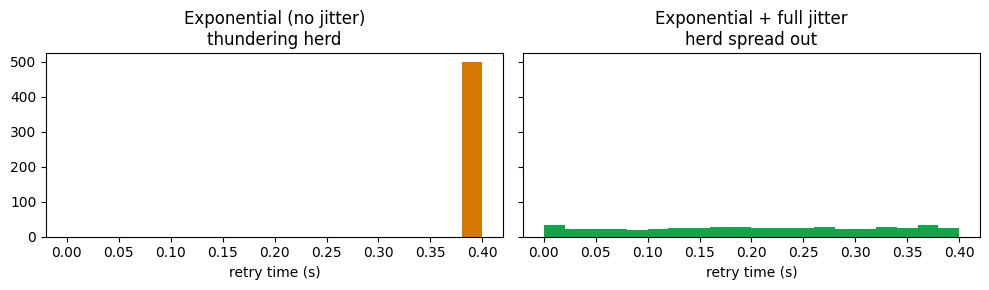

In [5]:
import matplotlib.pyplot as plt

base, cap = 0.05, 2.0
attempt = 3  # look at the 3rd retry
ceiling = min(cap, base * 2**attempt)

# each client's wait before the 3rd retry
exp_waits    = [ceiling for _ in range(500)]                       # everyone waits the same
jitter_waits = [random.uniform(0, ceiling) for _ in range(500)]    # spread out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
ax1.hist(exp_waits,    bins=20, range=(0, ceiling), color='#d97706')
ax1.set_title('Exponential (no jitter)\nthundering herd')
ax1.set_xlabel('retry time (s)')
ax2.hist(jitter_waits, bins=20, range=(0, ceiling), color='#16a34a')
ax2.set_title('Exponential + full jitter\nherd spread out')
ax2.set_xlabel('retry time (s)')
plt.tight_layout(); plt.show()


## 🌍 Real-world notes

- **Cap total wait**, not just per-retry: e.g. give up after 10s total, not 10 retries — beyond that, the user has left.
- **Only retry *idempotent* operations** (GETs, PUTs with a request id). Retrying a non-idempotent POST can double-charge a credit card.
- **Don't retry on `4xx`**: those are *your* fault (bad request), retrying won't help. Only retry on transient failures (`5xx`, timeouts, connection errors).
- **Budget retries across layers**: if service A retries 3× and calls B which retries 3×, B gets hit 9×. Usually only the outermost layer should retry.
- In production Python, use the [`tenacity`](https://tenacity.readthedocs.io/) library — it gives you `@retry(wait=wait_random_exponential(...), stop=stop_after_attempt(8))` out of the box.

## 🧠 Summary

| Strategy | Pros | Cons |
|---|---|---|
| Tight loop | quickest on transient blips | thundering herd — kills the downstream |
| Exponential | bounded total wait | clients sync up |
| **Exponential + full jitter** | spreads load, AWS-recommended | slightly more code |

Always cap retries (and total wait) — never retry forever.